<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Hosting Trade-off Analysis for LLM Systems**

Estimated time needed: **35** minutes


## Overview

Enterprise teams rarely choose LLM hosting based on model quality alone. In real data engineering programs, the decision is constrained by latency budgets, per-request cost ceilings, compliance obligations, and reliability targets. This lab simulates that architectural decision process by combining a small workload signal with a structured hosting scorecard.

You will work as a platform-minded data engineer evaluating cloud, dedicated, on-prem, and hybrid hosting patterns. This mirrors real-world use cases such as regulated document intelligence, AI-enabled support copilots, and internal analytics assistants where response time, governance, and spending discipline are all first-class requirements.

By the end of the lab, you will build a transparent recommendation workflow that ranks hosting options and tests whether the recommendation remains stable when enterprise priorities shift.


<h2>Table of Contents</h2>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="#Materials-and-Methods">Materials and Methods</a></li>
        <li><a href="#Dataset-Requirements">Dataset Requirements</a></li>
        <li><a href="#Objectives">Objectives</a></li>
        <li><a href="#Setup,-Installations,-and-Data-Checks">Setup, Installations, and Data Checks</a></li>
        <li><a href="#Baseline-Workload-Model">Baseline Workload Model</a></li>
        <li><a href="#Hosting-Option-Profiles">Hosting Option Profiles</a></li>
        <li><a href="#Recommendation-Engine">Recommendation Engine</a></li>
        <li><a href="#Sensitivity-Analysis">Sensitivity Analysis</a></li>
        <li><a href="#Student-Tasks">Student Tasks</a></li>
        <li><a href="#Conclusion">Conclusion</a></li>
        <li><a href="#Author">Author</a></li>
    </ol>
</div>


## Materials and Methods

This lab combines three practical components:

- A lightweight supervised classifier built with a **[Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)** and **[LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)** to simulate a baseline workload-quality signal.
- A structured hosting scorecard represented in a Pandas table for cloud, dedicated, on-prem, and hybrid options.
- A weighted multi-criteria decision method to rank options by enterprise priorities.

The central theme is **Architectural Trade-offs**: speed vs. governance, latency vs. operating cost, and compliance depth vs. deployment flexibility. In enterprise AI, a technically superior model can still be the wrong platform choice if it violates latency or policy constraints.


## Dataset Requirements

For fast, deterministic execution, this lab uses the built-in **[Breast Cancer dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)** from `sklearn.datasets`.

This dataset is provided under the <a href="https://opensource.org/licenses/BSD-3-Clause" target="_blank">BSD 3-Clause</a> license and is safe for commercial use.


## Objectives

After completing this lab, you will be able to:

- Compare hosting options across latency, cost, and compliance criteria.
- Produce a recommendation aligned with enterprise requirements.


## Setup, Installations, and Data Checks

We begin by preparing a reproducible environment. The installation cell uses a quiet command so notebook output stays clean and focused.

After installation, we import libraries in a dedicated step and then apply baseline data governance checks: schema validation, null scanning, and duplicate detection. These checks mirror CI/CD guardrails used in enterprise data platforms.


In [1]:
%pip install -q pandas scikit-learn seaborn matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


The environment should now contain the core analytics stack. Next, we import modules in one place for clarity and maintainability.

Reference docs: **[pandas](https://pandas.pydata.org/docs/)**, **[NumPy](https://numpy.org/doc/)**, **[Seaborn](https://seaborn.pydata.org/)**, and **[scikit-learn](https://scikit-learn.org/stable/user_guide.html)**.


In [2]:
# Core data engineering and analytics libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Utilities for modeling and evaluation.
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

We now load the built-in dataset and convert it into a single DataFrame, which is a common pattern before adding validation and transformation steps.

This step follows the official **[load_breast_cancer](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)** API and gives us both feature columns and a binary target label.


In [3]:
# Load the built-in dataset as a Pandas-friendly frame.
dataset = load_breast_cancer(as_frame=True)

# Keep one unified table for data checks and modeling.
df = dataset.frame.copy()
target_col = "target"

# Display quick structural context.
print("Shape:", df.shape)
df.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


The table preview confirms we have a ready-to-model structure. Before any model training, enterprise teams typically enforce baseline quality gates.

In practice, this means checking schema consistency, missingness, and duplicate records to reduce preventable incidents in production pipelines.


In [4]:
# Capture schema to validate expected column typing.
schema_df = df.dtypes.reset_index()
schema_df.columns = ["column", "dtype"]

# Measure missingness for data governance controls.
null_summary = df.isnull().sum()

# Detect exact duplicates that could bias metrics.
duplicate_count = df.duplicated().sum()

print("Total null values:", int(null_summary.sum()))
print("Duplicate rows:", int(duplicate_count))
schema_df.head(10)

Total null values: 0
Duplicate rows: 0


,column,dtype
0,mean radius,float64
1,mean texture,float64
2,mean perimeter,float64
3,mean area,float64
4,mean smoothness,float64
5,mean compactness,float64
6,mean concavity,float64
7,mean concave points,float64
8,mean symmetry,float64
9,mean fractal dimension,float64


These checks provide confidence that downstream performance signals are meaningful. We also inspect target balance, because class skew can distort quality estimates and, in turn, infrastructure decisions.

Reference: **[value_counts](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html)** and **[countplot](https://seaborn.pydata.org/generated/seaborn.countplot.html)**.


Class balance (%):
target
1    62.74
0    37.26


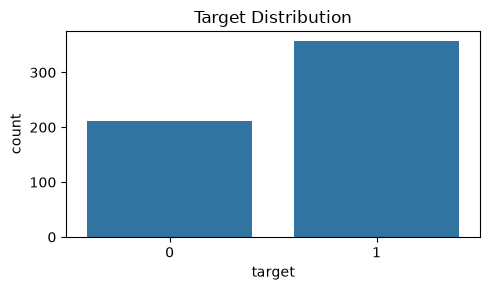

In [5]:
# Quantify class balance as normalized proportions.
class_balance = df[target_col].value_counts(normalize=True).rename("share")
class_balance_pct = (class_balance * 100).round(2)

# Print an interpretable summary for governance notes.
print("Class balance (%):")
print(class_balance_pct.to_string())

# Visual check of class frequencies.
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x=target_col)
plt.title("Target Distribution")
plt.tight_layout()
plt.show()

## Baseline Workload Model

To ground hosting decisions in measurable behavior, we train a compact baseline model and capture quality signals. The model itself is not the final product; it is a workload proxy that helps us reason about expected serving sensitivity.

We use **[train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)** to create a hold-out set, then combine preprocessing and classification with **[Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)**.


In [6]:
# Separate features and label for supervised learning.
X = df.drop(columns=[target_col])
y = df[target_col]

# Keep class ratios stable across splits.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (426, 30)
Test shape: (143, 30)


With data partitioned, we can fit a simple classifier and track quality metrics. In enterprise evaluation, these metrics are often paired with infrastructure metrics to avoid optimizing one dimension in isolation.

Metric references: **[accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)** and **[f1_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)**.


In [7]:
# Build a compact baseline pipeline for repeatable modeling.
model = Pipeline(
    steps=[("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000))]
)

# Fit and evaluate the baseline model.
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_f1 = f1_score(y_test, y_pred)

print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline F1 score: {baseline_f1:.4f}")

Baseline accuracy: 0.9860
Baseline F1 score: 0.9889


The baseline quality score acts as a workload-quality proxy for downstream hosting comparisons. Next, we model candidate hosting patterns and attach operational attributes used in architecture reviews.

This creates a bridge between ML performance and platform engineering constraints.


## Hosting Option Profiles

Each row below represents a plausible enterprise serving pattern with latency, unit cost, compliance depth, and SLA characteristics.

The values are illustrative and intentionally compact so you can focus on trade-off logic rather than infrastructure provisioning details.


In [8]:
# Define candidate hosting options for enterprise LLM serving.
hosting_profiles = pd.DataFrame(
    [
        {
            "option": "Managed Cloud API",
            "latency_ms": 320,
            "cost_per_1k_usd": 0.018,
            "compliance_score": 0.70,
            "availability_sla": 0.995,
        },
        {
            "option": "Dedicated VPC Endpoint",
            "latency_ms": 260,
            "cost_per_1k_usd": 0.026,
            "compliance_score": 0.86,
            "availability_sla": 0.999,
        },
        {
            "option": "On-Prem GPU Cluster",
            "latency_ms": 180,
            "cost_per_1k_usd": 0.031,
            "compliance_score": 0.95,
            "availability_sla": 0.992,
        },
        {
            "option": "Hybrid Routing",
            "latency_ms": 210,
            "cost_per_1k_usd": 0.024,
            "compliance_score": 0.92,
            "availability_sla": 0.998,
        },
    ]
)

# Add quality alignment using the baseline workload signal.
hosting_profiles["quality_alignment"] = (
    baseline_f1 * np.array([0.98, 1.00, 1.02, 1.01])
).round(4)
hosting_profiles

,option,latency_ms,cost_per_1k_usd,compliance_score,availability_sla,quality_alignment
0,Managed Cloud API,320,0.018,0.70,0.995,0.9691
1,Dedicated VPC Endpoint,260,0.026,0.86,0.999,0.9889
2,On-Prem GPU Cluster,180,0.031,0.95,0.992,1.0087
3,Hybrid Routing,210,0.024,0.92,0.998,0.9988


Notice that no option dominates every metric. This is exactly why architectural selection requires explicit constraints and transparent weighting.

We now formalize enterprise requirements and score the feasible options.


## Recommendation Engine

The recommendation engine applies two stages:

- Hard constraints (for example, minimum compliance thresholds).
- Weighted optimization over normalized metrics for latency, cost, compliance, and quality alignment.

This pattern mirrors architecture review boards where some requirements are non-negotiable while others are optimized.


In [9]:
# Enterprise guardrails and balanced weighting policy.
enterprise_requirements = {
    "max_latency_ms": 280,
    "max_cost_per_1k_usd": 0.030,
    "min_compliance_score": 0.85,
}

weights = {
    "latency_score": 0.35,
    "cost_score": 0.30,
    "compliance_score_norm": 0.25,
    "quality_alignment_norm": 0.10,
}

print(enterprise_requirements)
print(weights)

{'max_latency_ms': 280, 'max_cost_per_1k_usd': 0.03, 'min_compliance_score': 0.85}
{'latency_score': 0.35, 'cost_score': 0.3, 'compliance_score_norm': 0.25, 'quality_alignment_norm': 0.1}


With policy defined, we transform raw metrics into comparable scores. Lower latency and lower cost are better, so we invert those dimensions during normalization.

This keeps the final weighted score interpretable: higher means better overall fit.


In [10]:
# Keep only options that satisfy mandatory compliance requirements.
feasible_options = hosting_profiles[
    hosting_profiles["compliance_score"]
    >= enterprise_requirements["min_compliance_score"]
].copy()

# Normalize metrics so all criteria can be combined fairly.
feasible_options["latency_score"] = 1 - (
    feasible_options["latency_ms"] / feasible_options["latency_ms"].max()
)
feasible_options["cost_score"] = 1 - (
    feasible_options["cost_per_1k_usd"] / feasible_options["cost_per_1k_usd"].max()
)
feasible_options["compliance_score_norm"] = feasible_options["compliance_score"]
feasible_options["quality_alignment_norm"] = (
    feasible_options["quality_alignment"] / feasible_options["quality_alignment"].max()
)

feasible_options[
    [
        "option",
        "latency_score",
        "cost_score",
        "compliance_score_norm",
        "quality_alignment_norm",
    ]
]

,option,latency_score,cost_score,compliance_score_norm,quality_alignment_norm
1,Dedicated VPC Endpoint,0.000000,0.161290,0.86,0.980371
2,On-Prem GPU Cluster,0.307692,0.000000,0.95,1.000000
3,Hybrid Routing,0.192308,0.225806,0.92,0.990185


Now we combine normalized dimensions using the selected weight policy and produce a ranked recommendation table for decision review.


In [11]:
# Compute weighted score using the current enterprise priorities.
ranked_options = feasible_options.copy()
ranked_options["weighted_score"] = sum(
    ranked_options[col] * weight for col, weight in weights.items()
)

# Rank options and expose the top recommendation.
ranked_options = ranked_options.sort_values(
    "weighted_score", ascending=False
).reset_index(drop=True)
best_option = ranked_options.iloc[0]

print("Recommended option:", best_option["option"])
ranked_options[
    ["option", "latency_ms", "cost_per_1k_usd", "compliance_score", "weighted_score"]
]

Recommended option: Hybrid Routing


,option,latency_ms,cost_per_1k_usd,compliance_score,weighted_score
0,Hybrid Routing,210,0.024,0.92,0.464068
1,On-Prem GPU Cluster,180,0.031,0.95,0.445192
2,Dedicated VPC Endpoint,260,0.026,0.86,0.361424


The top row is your current recommendation under balanced priorities. To communicate the trade-off profile to stakeholders, we visualize the core metrics side by side.

Reference: **[seaborn.barplot](https://seaborn.pydata.org/generated/seaborn.barplot.html)**.


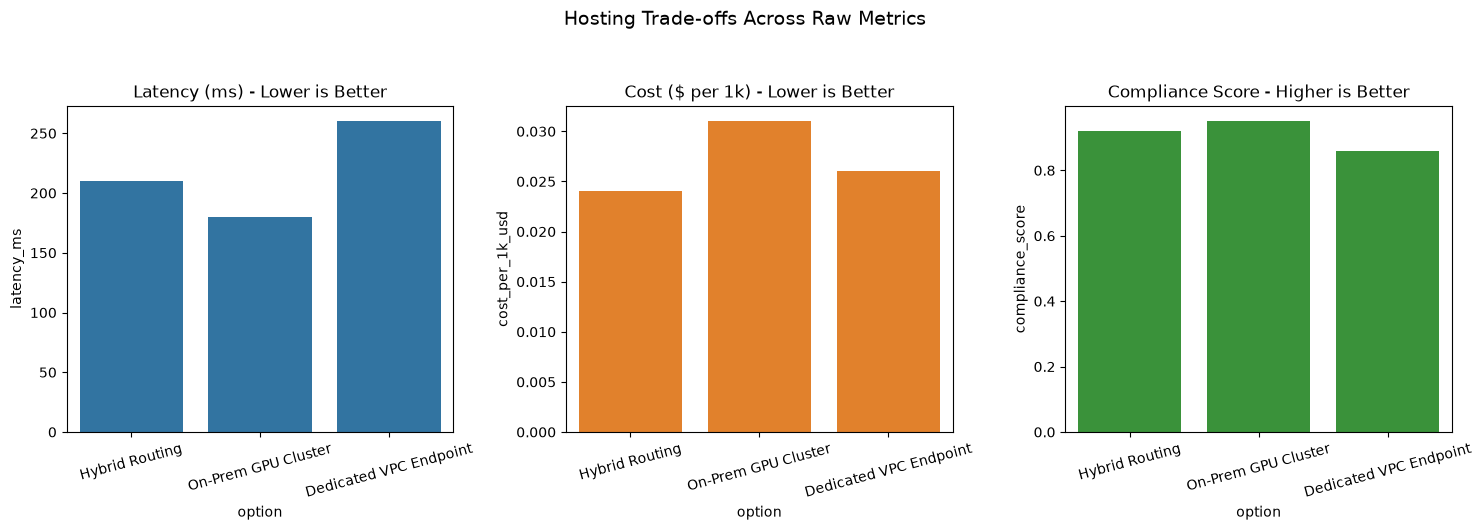

In [12]:
# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot Latency
sns.barplot(
    data=ranked_options, x="option", y="latency_ms", ax=axes[0], color="tab:blue"
)
axes[0].set_title("Latency (ms) - Lower is Better")
axes[0].tick_params(axis="x", rotation=15)

# Plot Cost
sns.barplot(
    data=ranked_options, x="option", y="cost_per_1k_usd", ax=axes[1], color="tab:orange"
)
axes[1].set_title("Cost ($ per 1k) - Lower is Better")
axes[1].tick_params(axis="x", rotation=15)

# Plot Compliance
sns.barplot(
    data=ranked_options, x="option", y="compliance_score", ax=axes[2], color="tab:green"
)
axes[2].set_title("Compliance Score - Higher is Better")
axes[2].tick_params(axis="x", rotation=15)

plt.suptitle("Hosting Trade-offs Across Raw Metrics", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

The chart highlights that the best weighted option is not necessarily the best on every individual metric. This is the expected outcome of intentional multi-objective optimization.

To strengthen the recommendation, we now test whether it remains stable under alternative priority sets.


## Sensitivity Analysis

Sensitivity analysis answers a critical governance question: does the recommendation change when business strategy changes?

We evaluate latency-first, cost-first, and compliance-first scenarios by adjusting criterion weights and selecting the top-ranked option in each case.


In [13]:
# Define alternate strategic priorities for what-if analysis.
scenario_weights = {
    "Latency-first": {
        "latency_score": 0.50,
        "cost_score": 0.20,
        "compliance_score_norm": 0.20,
        "quality_alignment_norm": 0.10,
    },
    "Cost-first": {
        "latency_score": 0.20,
        "cost_score": 0.50,
        "compliance_score_norm": 0.20,
        "quality_alignment_norm": 0.10,
    },
    "Compliance-first": {
        "latency_score": 0.20,
        "cost_score": 0.20,
        "compliance_score_norm": 0.50,
        "quality_alignment_norm": 0.10,
    },
}

# Evaluate the top option for each strategy profile.
benchmark_rows = []
for name, w in scenario_weights.items():
    temp = feasible_options.copy()
    temp["scenario_score"] = sum(temp[col] * weight for col, weight in w.items())
    best = temp.sort_values("scenario_score", ascending=False).iloc[0]
    benchmark_rows.append(
        {
            "scenario": name,
            "recommended_option": best["option"],
            "score": round(best["scenario_score"], 4),
        }
    )

scenario = pd.DataFrame(benchmark_rows)
scenario

,scenario,recommended_option,score
0,Latency-first,On-Prem GPU Cluster,0.4438
1,Cost-first,Hybrid Routing,0.4344
2,Compliance-first,Hybrid Routing,0.6426


If one option wins across multiple scenarios, your recommendation is robust. If winners vary sharply, decision makers may need a policy-based tie-breaker (for example, strict compliance preference in regulated domains).

This is why enterprise architecture reviews should always include sensitivity analysis, not just a single weighted snapshot.


## Student Tasks

Use the tasks below to practice translating business constraints into a quantitative hosting recommendation.


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #1: </h1>
<b>Adjust the weight policy for a highly regulated enterprise (higher compliance weight), then recompute the top recommendation.</b>
</div>


In [14]:
# TODO: Create a new weights dictionary that emphasizes compliance.
# TODO: Recompute weighted scores with the new policy.
# TODO: Sort the options and print the new top recommendation.

regulated_weights = {
    "latency_score": 0.20,
    "cost_score": 0.15,
    "compliance_score_norm": 0.55,
    "quality_alignment_norm": 0.10,
}

regulated_ranked = feasible_options.copy()
regulated_ranked["regulated_score"] = sum(
    regulated_ranked[col] * weight for col, weight in regulated_weights.items()
)

regulated_ranked = regulated_ranked.sort_values(
    "regulated_score", ascending=False
).reset_index(drop=True)
print("Regulated top option:", regulated_ranked.loc[0, "option"])
regulated_ranked[["option", "regulated_score"]]

Regulated top option: On-Prem GPU Cluster


,option,regulated_score
0,On-Prem GPU Cluster,0.684038
1,Hybrid Routing,0.677351
2,Dedicated VPC Endpoint,0.595231


<details><summary>Click here for the solution</summary>

```python
regulated_weights = {
    "latency_score": 0.20,
    "cost_score": 0.15,
    "compliance_score_norm": 0.55,
    "quality_alignment_norm": 0.10
}

regulated_ranked = feasible_options.copy()
regulated_ranked["regulated_score"] = sum(
    regulated_ranked[col] * weight for col, weight in regulated_weights.items()
)

regulated_ranked = regulated_ranked.sort_values("regulated_score", ascending=False).reset_index(drop=True)
print("Regulated top option:", regulated_ranked.loc[0, "option"])
regulated_ranked[["option", "regulated_score"]]
```

</details>


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #2: </h1>
<b>Apply a strict latency policy (maximum 220 ms) and identify which options remain feasible before scoring.</b>
</div>


In [15]:
# TODO: Filter hosting_profiles to latency <= 220 ms.
# TODO: Display the remaining options and key metrics.
# TODO: Briefly inspect whether compliance is still acceptable.

strict_latency = 220
latency_feasible = hosting_profiles[
    hosting_profiles["latency_ms"] <= strict_latency
].copy()

print("Options meeting latency policy:")
print(
    latency_feasible[
        ["option", "latency_ms", "compliance_score", "cost_per_1k_usd"]
    ].to_string(index=False)
)

Options meeting latency policy:
             option  latency_ms  compliance_score  cost_per_1k_usd
On-Prem GPU Cluster         180              0.95            0.031
     Hybrid Routing         210              0.92            0.024


<details><summary>Click here for the solution</summary>

```python
strict_latency = 220
latency_feasible = hosting_profiles[hosting_profiles["latency_ms"] <= strict_latency].copy()

print("Options meeting latency policy:")
print(latency_feasible[["option", "latency_ms", "compliance_score", "cost_per_1k_usd"]].to_string(index=False))
```

</details>


## Conclusion

You implemented a practical enterprise decision flow for LLM hosting: baseline workload signal, quality checks, hard constraints, weighted ranking, and sensitivity testing.

For the default balanced policy in this lab, the recommended option is **Hybrid Routing**, which provides a strong balance of latency, cost, and compliance without violating enterprise constraints.


## Author

<a href="https://author.skills.network/instructors/dmytro_shliakhovskyi">Dmytro Shliakhovskyi</a>

## Change Log
| Date (YYYY-MM-DD) | Version | Changed By | Change Description |
| ----------------- | ------- | ---------- | ------------------ |
| 2026-04-27 | 01 | Dmytro Shliakhovskyi | Lab created |

<h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>
